# Mean-Variance Portfolio Optimization with cuOpt

<div style="background-color: #e3f2fd; border-left: 6px solid #1976d2; padding: 15px; margin: 15px 0;">
<h4 style="margin-top: 0;">📘 Optional Notebook</h4>
We now support solving <strong>Quadratic Programs (QP)</strong>, enabling standard <strong>Markowitz Mean-Variance</strong> portfolio optimization directly on the GPU.

This notebook shows how the same framework extends to QP problems with a quadratic objective with variance as the risk measure <code>w'Σw</code>.
</div>


## Table of Contents

1. [Setup](#setup) — GPU check & imports
2. [Mathematical Formulation](#introduction) — The Markowitz QP
3. [Solve with cuOpt](#solve) — Data, parameters & GPU optimization
4. [Results](#analyze) — Portfolio visualization & statistics
5. [CPU Solver Comparison](#cpu-comparison) — Clarabel vs cuOpt


---

<a id='setup'></a>
## 1. Setup


In [1]:
!nvidia-smi

limit: No such limit.


Mon Jul 27 08:26:28 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 595.58.03              Driver Version: 595.58.03      CUDA Version: 13.2     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|


|   0  NVIDIA H200                    On  |   00000000:9D:00.0 Off |                    0 |
| N/A   31C    P0             79W /  700W |       0MiB / 143771MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+------------------------+----------------------+
|   1  NVIDIA H200                    On  |   00000000:C3:00.0 Off |                    0 |
| N/A   30C    P0             78W /  700W |       0MiB / 143771MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+------------------------+----------------------+
|   2  NVIDIA H200                    On  |   00000000:D1:00.0 Off |                    0 |
| N/A   32C    P0             80W /  700W |       0MiB / 143771MiB |      0%      Default |
|                                         |                        |            

In [2]:
import os

import numpy as np
import cvxpy as cp

from cufolio import mean_variance_optimizer, utils
from cufolio.mean_variance_parameters import MeanVarianceParameters
from cufolio.settings import ApiSettings, ReturnsComputeSettings

---

<a id='introduction'></a>
## 2. Mathematical Formulation

<div style="background-color: #f3e5f5; border-left: 6px solid #9c27b0; padding: 15px; margin: 15px 0;">
<h4 style="margin-top: 0;">💡 Mean-Variance (Markowitz) Optimization</h4>
Mean-Variance optimization, introduced by Harry Markowitz in 1952, is the foundation of Modern Portfolio Theory. The objective trades off expected return against portfolio variance:

\begin{align*}
\text{maximize } \quad &\mu^\top w - \lambda_{\text{risk}} \cdot w^\top \Sigma w\\
\text{subject to} \quad 
& \sum_i w_i + c = 1 \quad \text{(self-financing)}\\
& w_i^{\text{min}} \leq w_i \leq w_i^{\text{max}}, \forall i \quad \text{(concentration)}\\
& c^{\text{min}} \leq c \leq c^{\text{max}} \quad \text{(cash)}\\
& L = \|w\|_1 \leq L^{\text{limit}} \quad \text{(leverage)}\\
& T = \|w - w_{\text{prev}}\|_1 \leq T^{\text{limit}} \quad \text{(turnover)}
\end{align*}

This is a **Quadratic Program (QP)** due to the $w^\top \Sigma w$ term. cuOpt 26.02 introduces QP support via a GPU-accelerated barrier solver.
</div>


---

<a id='solve'></a>
## 3. Solve with cuOpt

<div style="background-color: #e8f5e9; border-left: 6px solid #388e3c; padding: 15px; margin: 15px 0;">
<h4 style="margin-top: 0;">🚀 End-to-End: Data → Parameters → GPU Solve</h4>
We load S&P 500 price data, compute log-returns, define portfolio constraints, and solve the QP on the GPU using cuOpt.
</div>

<div style="background-color: #fff8e1; border-left: 6px solid #f9a825; padding: 15px; margin: 15px 0;">
<h4 style="margin-top: 0;">⚠️ Disclaimer</h4>
Each user is responsible for checking the content of datasets and the applicable licenses and determining if suitable for the intended use.
</div>


In [3]:
dataset_name = "sp500"
data_path = f"../data/stock_data/{dataset_name}.csv"

if not os.path.exists(data_path):
    utils.download_data(data_path)

returns_dict = utils.calculate_returns(
    data_path,
    {"name": "recent", "range": ("2022-01-01", "2024-01-01")},
    ReturnsComputeSettings(return_type="LOG", freq=1),
)

print(f"Assets: {len(returns_dict['tickers'])}  |  "
      f"Observations: {len(returns_dict['returns'])}  |  "
      f"Covariance: {returns_dict['covariance'].shape}")


Assets: 386  |  Observations: 500  |  Covariance: (386, 386)


In [4]:
mean_variance_params = MeanVarianceParameters(
    w_min={"NVDA": 0.1, "others": -0.3},
    w_max={"NVDA": 0.6, "others": 0.4},
    c_min=0.0,
    c_max=0.2,
    L_tar=1.6,
    risk_aversion=1.0,
)


### Solve with CVXPY API

In [5]:
mean_variance_problem = mean_variance_optimizer.MeanVariance(
    returns_dict=returns_dict,
    mean_variance_params=mean_variance_params,
    api_settings=ApiSettings(api="cvxpy"),
)

cvxpy_gpu_results, cvxpy_gpu_portfolio = mean_variance_problem.solve_optimization_problem(
    solver_settings={"solver": cp.CUOPT, "time_limit": 60, "verbose": True}
)

(CVXPY) Jul 27 08:26:41 AM: Your problem has 387 variables, 2 constraints, and 2 parameters.


(CVXPY) Jul 27 08:26:41 AM: It is compliant with the following grammars: DCP, DQCP


(CVXPY) Jul 27 08:26:41 AM: DCP verification time: 0.0003 seconds.


(CVXPY) Jul 27 08:26:41 AM: Expression tree has 8 nodes.


(CVXPY) Jul 27 08:26:41 AM: CVXPY will first compile your problem; then, it will invoke a numerical solver to obtain a solution.


...

(CVXPY) Jul 27 08:26:42 AM: Problem status: optimal


(CVXPY) Jul 27 08:26:42 AM: Optimal value: -2.892e-03


(CVXPY) Jul 27 08:26:42 AM: Compilation took 9.797e-02 seconds


(CVXPY) Jul 27 08:26:42 AM: Solver (including time spent in interface) took 1.104e+00 seconds




                  Objective                         Infeasibility        Time
Iter   Primal              Dual                Primal   Dual    Compl.   Elapsed
  0   +6.201036237720e+08 -6.201247433616e+08 5.90e+04 3.86e+02 3.42e-04 0.5
  1   +5.939670717089e+08 -5.939880559282e+08 5.77e+04 3.77e+02 3.49e-04 0.5
  2   +5.887900947376e+08 -5.888110438583e+08 5.74e+04 3.76e+02 3.51e-04 0.5
  3   +5.452344275917e+08 -5.452550162637e+08 5.54e+04 3.62e+02 4.33e-04 0.5
  4   +4.591265610500e+08 -4.591463429701e+08 5.08e+04 3.32e+02 6.66e-04 0.5
  5   +2.519077700004e+08 -2.519247400408e+08 3.76e+04 2.46e+02 1.90e-03 0.5
  6   +7.872201039917e+06 -7.880382329431e+06 6.65e+03 4.35e+01 5.32e-02 0.6
  7   +7.915174898694e+04 -8.528796661995e+04 6.67e+02 4.36e+00 5.95e-01 0.6
  8   +8.358467097950e+02 -6.052608930753e+03 6.86e+01 4.48e-01 5.84e+00 0.6
  9   +1.423979054891e+01 -2.781056296074e+03 8.95e+00 5.85e-02 4.34e+01 0.6
 10   +7.751001610966e-01 -1.628574069997e+03 2.08e+00 1.36e-02 9.92e

### Solve using cuOpt Python API

In [6]:
mean_variance_problem = mean_variance_optimizer.MeanVariance(
    returns_dict=returns_dict,
    mean_variance_params=mean_variance_params,
    api_settings=ApiSettings(api="cuopt_python"),
)

gpu_results, gpu_portfolio = mean_variance_problem.solve_optimization_problem(
    solver_settings={"time_limit": 60, "log_to_console": True}
)

cuOpt MEAN-VARIANCE PROBLEM SETUP COMPLETED
Variables: 386 weights + 1 cash + 772 leverage aux
Covariance matrix: 386x386
Linear terms: 386
Problem Type: QP (Quadratic Programming)
Setting parameter time_limit to 6.000000e+01
Setting parameter log_to_console to true
cuOpt version: 26.6.0, git hash: df5fe0d1, host arch: x86_64, device archs: 70-real,75-real,80-real,86-real,90a-real,100f-real,120a-real,120
CPU: Intel(R) Xeon(R) Platinum 8480CL, threads (physical/logical): 112/224, RAM: 1904.27 GiB
CUDA 12.9, device: NVIDIA H200 (ID 0), VRAM: 139.80 GiB
CUDA device UUID: 6131babb-de15-a005-cd00-d15dca1e909a

Problem has a quadratic objective. Solving with barrier.
Transforming 386 nonzero lower bound
Presolved problem: 388 constraints 1160 variables 2318 nonzeros
Skipping Ruiz equilibration (row norm ratio 1.0 < 100)
Barrier solver started at 0.00 seconds
Barrier solver: 388 constraints, 1160 variables, 2318 nonzeros


Quadratic objective matrix  : 148996 nonzeros
Upper bounds            

cuOpt solution found in 0.1601 seconds
Status: Optimal
Objective value: -0.002892

MEAN-VARIANCE OPTIMIZATION RESULTS
PROBLEM CONFIGURATION
------------------------------
Solver:              cuOpt
Regime:              recent
Time Period:         2022-01-01 to 2024-01-01
Assets:              386

PERFORMANCE METRICS
------------------------------
Expected Return:     0.002914 (0.2914%)
Variance:            0.000235
Std Deviation:       0.015327
Objective Value:     -0.002892

SOLVING PERFORMANCE
------------------------------
Setup Time:          0.0267 seconds
cuOpt API Overhead:  0.0157 seconds
Solve Time:          0.1601 seconds

OPTIMAL PORTFOLIO ALLOCATION
------------------------------

PORTFOLIO: CUOPT_OPTIMAL
----------------------------------------
Period: 2022-01-01 to 2024-01-01

LONG POSITIONS (4 assets)
-------------------------
FICO        0.400 ( 40.00%)
LLY         0.400 ( 40.00%)
CAH         0.300 ( 30.00%)
NVDA        0.100 ( 10.00%)
Total Long    1.200 (120.00%)

SHO

---

<a id='analyze'></a>
## 4. Results


<div style="background-color: #fff8e1; border-left: 6px solid #f9a825; padding: 15px; margin: 15px 0;">
<h4 style="margin-top: 0;">📏 Units — every statistic here is daily</h4>
Returns were computed as <strong>1-day log returns</strong> (<code>ReturnsComputeSettings(return_type="LOG", freq=1)</code>), so the expected return, volatility, and variance in the solver printouts above and the statistics below are <strong>daily</strong> quantities, not annualized. Daily log returns annualize additively: a daily expected log return of 0.29% is about a 73% annualized <em>log</em> return, i.e. <code>e^0.73 − 1 ≈ 108%</code> annualized <em>simple</em> return. These are in-sample historical means over the selected regime window — an artifact of the optimizer selecting the sample's best performers, not a return forecast.
</div>


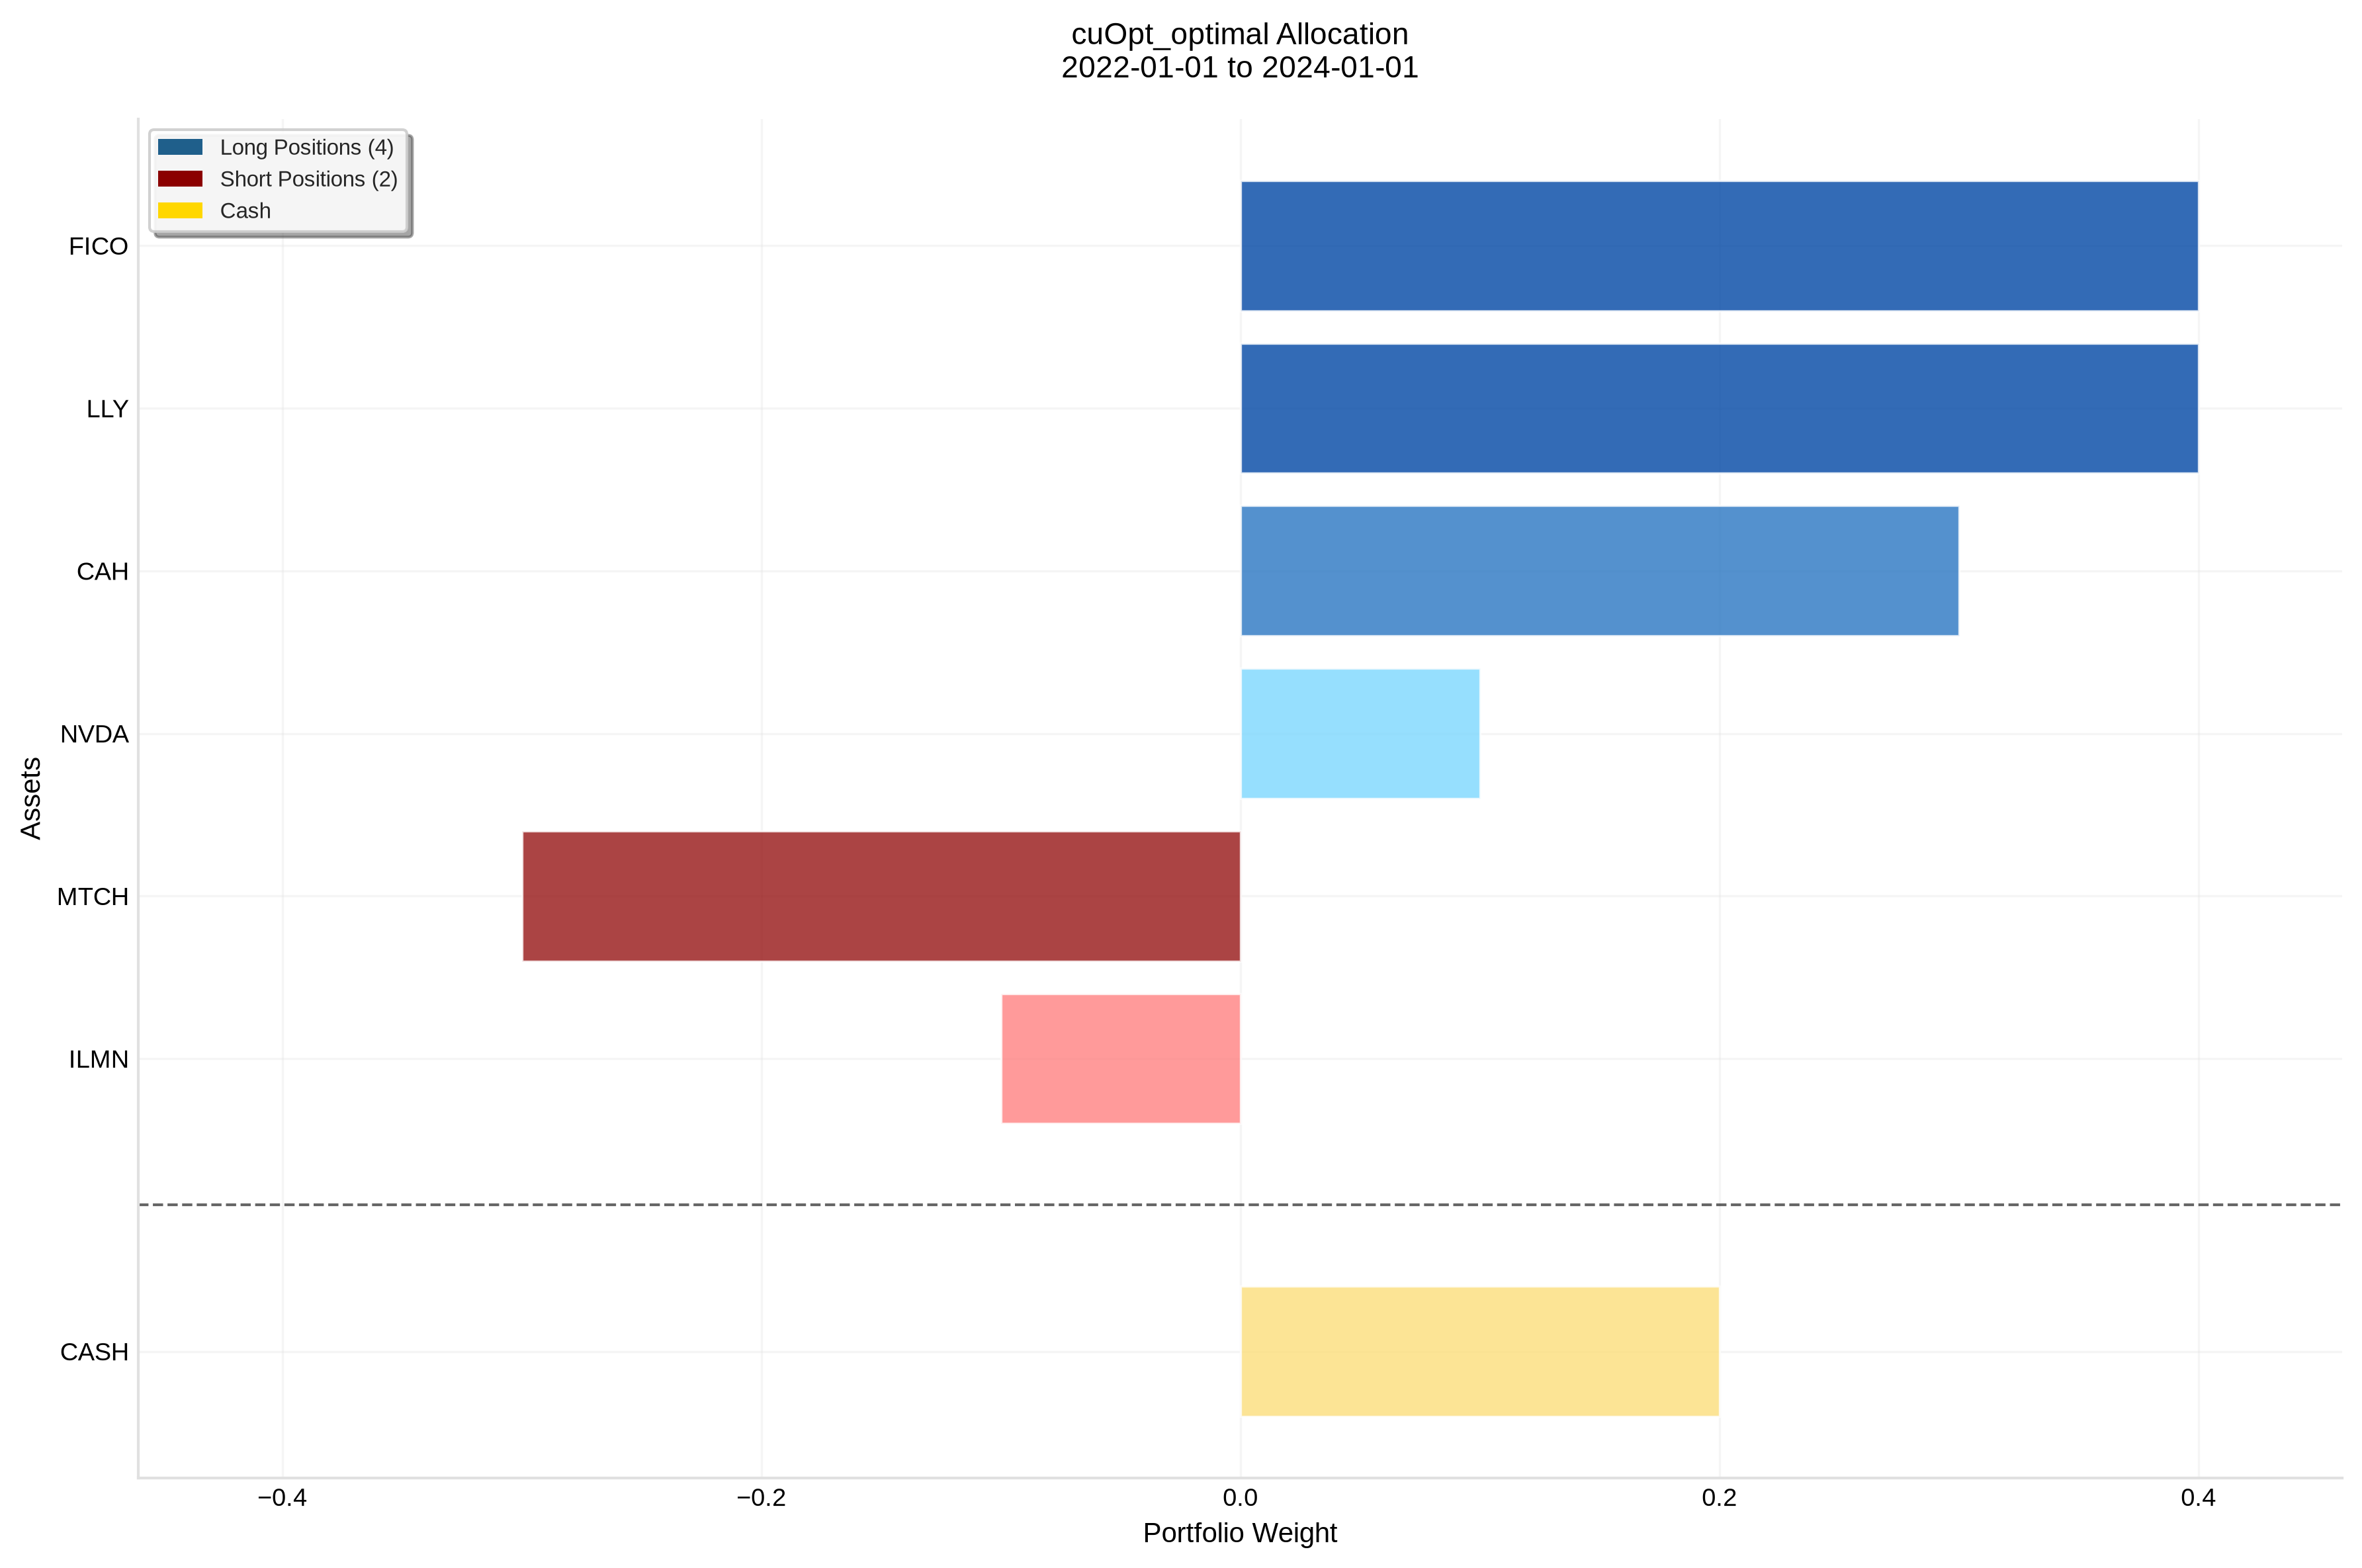

In [7]:
ax = gpu_portfolio.plot_portfolio(show_plot=True, min_percentage=1)


In [8]:
weights = gpu_portfolio.weights

expected_return = np.dot(returns_dict["mean"], weights)
portfolio_variance = weights @ returns_dict["covariance"] @ weights
portfolio_std = np.sqrt(portfolio_variance)
sharpe_ratio = expected_return / portfolio_std if portfolio_std > 0 else 0

# Inputs are 1-day LOG returns, so the statistics above are all DAILY figures.
# Log returns annualize additively (x252); volatility scales with sqrt(252).
TRADING_DAYS = 252
annual_log_return = expected_return * TRADING_DAYS
annual_simple_return = np.exp(annual_log_return) - 1
annual_volatility = portfolio_std * np.sqrt(TRADING_DAYS)
annual_sharpe = sharpe_ratio * np.sqrt(TRADING_DAYS)

cash = float(np.asarray(gpu_portfolio.cash).squeeze())

print("Portfolio Statistics (daily, from 1-day log returns):")
print(f"  Expected Return:  {expected_return:.4%} per day")
print(f"  Volatility (Std): {portfolio_std:.4%} per day")
print(f"  Variance:         {portfolio_variance:.6f}")
print(f"  Sharpe Ratio:     {sharpe_ratio:.4f}")
print(f"  Cash Allocation:  {cash:.2%}")
print(f"  Leverage:         {np.sum(np.abs(weights)):.4f}")
print(f"  Number of positions: {np.sum(np.abs(weights) > 0.001)}")
print()
print("Annualized (252 trading days, in-sample):")
print(f"  Log Return:    {annual_log_return:.2%}")
print(f"  Simple Return: {annual_simple_return:.2%}")
print(f"  Volatility:    {annual_volatility:.2%}")
print(f"  Sharpe Ratio:  {annual_sharpe:.2f}")


Portfolio Statistics (daily, from 1-day log returns):
  Expected Return:  0.2914% per day
  Volatility (Std): 1.5327% per day
  Variance:         0.000235
  Sharpe Ratio:     0.1901
  Cash Allocation:  20.00%
  Leverage:         1.6000
  Number of positions: 6

Annualized (252 trading days, in-sample):
  Log Return:    73.43%
  Simple Return: 108.40%
  Volatility:    24.33%
  Sharpe Ratio:  3.02


---

<a id='cpu-comparison'></a>
## 5. CPU Solver Comparison

<div style="background-color: #fff3e0; border-left: 6px solid #f57c00; padding: 15px; margin: 15px 0;">
<h4 style="margin-top: 0;">🔄 GPU vs CPU</h4>
Solve the same Mean-Variance problem using <strong>Clarabel</strong> (a CPU-based interior-point solver) and compare the results against the GPU solution above. For small portfolios the GPU advantage in solve time alone may be modest, but running the entire pipeline on GPU — data preprocessing, returns forecasting, scenario generation, and optimization — eliminates costly CPU↔GPU data transfers and delivers end-to-end speedups that grow with problem size.
</div>

<div style="background-color: #fff8e1; border-left: 6px solid #f9a825; padding: 15px; margin: 15px 0;">
<h4 style="margin-top: 0;">⏱️ Timing methodology — cold-start solves</h4>
All committed solve times come from a single top-to-bottom execution on a cold kernel, so each solver pays its full one-time cost (CVXPY canonicalization, library initialization). Re-solving the same problem object in a warm session is roughly 40% faster for the CPU solver because CVXPY reuses its cached canonicalization — so interactive re-runs of this cell will report faster CPU times than a fresh end-to-end execution. Cold-start numbers are what a first-time reader reproduces.
</div>

In [9]:
cpu_problem = mean_variance_optimizer.MeanVariance(
    returns_dict=returns_dict,
    mean_variance_params=mean_variance_params,
    api_settings=ApiSettings(api="cvxpy"),
)

cpu_results, cpu_portfolio = cpu_problem.solve_optimization_problem(
    solver_settings={"solver": cp.CLARABEL}
)


MEAN-VARIANCE OPTIMIZATION RESULTS
PROBLEM CONFIGURATION
------------------------------
Solver:              CLARABEL
Regime:              recent
Time Period:         2022-01-01 to 2024-01-01
Assets:              386

PERFORMANCE METRICS
------------------------------
Expected Return:     0.002914 (0.2914%)
Variance:            0.000235
Std Deviation:       0.015327
Objective Value:     -0.002892

SOLVING PERFORMANCE
------------------------------
Setup Time:          0.0102 seconds
CVXPY API Overhead:  0.0224 seconds
Solve Time:          0.1957 seconds

OPTIMAL PORTFOLIO ALLOCATION
------------------------------

PORTFOLIO: CLARABEL_OPTIMAL
----------------------------------------
Period: 2022-01-01 to 2024-01-01

LONG POSITIONS (4 assets)
-------------------------
FICO        0.400 ( 40.00%)
LLY         0.400 ( 40.00%)
CAH         0.300 ( 30.00%)
NVDA        0.100 ( 10.00%)
Total Long    1.200 (120.00%)

SHORT POSITIONS (2 assets)
--------------------------
MTCH       -0.300 (-30.00

In [10]:
utils.compare_results(gpu_results.to_dict(), cpu_results.to_dict())


SOLVER COMPARISON
Solver          solve time   obj          return       variance    
----------------------------------------------------------------------
cuOpt (GPU)     0.160124     -0.002892    0.002914     0.000235    
CLARABEL (CPU)  0.195742     -0.002892    0.002914     0.000235    

Objective Differences:
  cuOpt (GPU) vs CLARABEL (CPU): 0.00000002



### Compare portfolio composition

`compare_results` above compares solve metrics (solver, time, objective, return, variance). To compare the **holdings**, line the weight vectors up side by side. Because the problem is convex with a single optimum, every solver should agree to solver tolerance (roughly `1e-4` per weight); return and objective agree far tighter.


In [11]:
import pandas as pd

composition = pd.DataFrame(
    {
        "cuOpt (direct)": np.asarray(gpu_portfolio.weights, dtype=float),
        "cuOpt (via CVXPY)": np.asarray(cvxpy_gpu_portfolio.weights, dtype=float),
        "CLARABEL (CPU)": np.asarray(cpu_portfolio.weights, dtype=float),
    },
    index=returns_dict["tickers"],
)
composition["GPU-CPU diff"] = composition["cuOpt (direct)"] - composition["CLARABEL (CPU)"]

top_positions = composition.reindex(
    composition["cuOpt (direct)"].abs().sort_values(ascending=False).index
).head(10)
display(top_positions.round(6))

gpu_cash = float(np.asarray(gpu_portfolio.cash).squeeze())
cpu_cash = float(np.asarray(cpu_portfolio.cash).squeeze())
print(f"max |GPU-CPU| weight difference: {composition['GPU-CPU diff'].abs().max():.2e}")
print(f"L1 weight difference:            {composition['GPU-CPU diff'].abs().sum():.2e}")
print(f"cash — cuOpt: {gpu_cash:.4f} | CLARABEL: {cpu_cash:.4f}")


,cuOpt (direct),cuOpt (via CVXPY),CLARABEL (CPU),GPU-CPU diff
FICO,0.399999,0.399999,0.4,-0.000001
LLY,0.399998,0.399998,0.4,-0.000002
MTCH,-0.299999,-0.299999,-0.3,0.000001
CAH,0.299994,0.299997,0.3,-0.000006
NVDA,0.100000,0.100000,0.1,0.000000
ILMN,-0.099997,-0.099998,-0.1,0.000003
STLD,0.000001,0.000000,0.0,0.000001
OXY,0.000001,0.000000,0.0,0.000001
PWR,0.000000,0.000000,0.0,0.000000
EL,-0.000000,-0.000000,-0.0,-0.000000


max |GPU-CPU| weight difference: 5.91e-06
L1 weight difference:            1.83e-05
cash — cuOpt: 0.2000 | CLARABEL: 0.2000


---

## Summary

<div style="background-color: #e8f5e9; border-left: 6px solid #388e3c; padding: 15px; margin: 15px 0;">
<h4 style="margin-top: 0;">✅ Key Takeaway</h4>
<strong>cuOpt >= 26.02</strong> adds QP support, enabling GPU-accelerated Markowitz Mean-Variance optimization alongside the existing LP-based CVaR solver. The same cuFOLIO framework handles both problem types — simply choose the appropriate optimizer class.

### Mean-Variance vs CVaR

| Aspect | Mean-Variance | CVaR |
|--------|---------------|------|
| Risk Measure | Variance (symmetric) | Tail risk (asymmetric) |
| Problem Type | QP (Quadratic) | LP (Linear) |
| Data Needed | Mean + Covariance | Scenarios |
| Distribution | Assumes normal | Distribution-free |

</div>
